In [2]:
pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import kagglehub

os.environ["KAGGLE_API_TOKEN"] = 'KGAT_48edbb733751dd217123dda3fc274d52'

path = kagglehub.competition_download("store-sales-time-series-forecasting")

print("Path to competition files:", path)

100%|██████████| 21.4M/21.4M [00:01<00:00, 13.3MB/s]

Extracting files...


Path to competition files: C:\Users\david\.cache\kagglehub\competitions\store-sales-time-series-forecasting


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Carga de archivos — ajusta la ruta si es necesario
train        = pd.read_csv('train.csv', parse_dates=['date'])
stores       = pd.read_csv('stores.csv')
oil          = pd.read_csv('oil.csv', parse_dates=['date'])
holidays     = pd.read_csv('holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('transactions.csv', parse_dates=['date'])

# Revisión rápida
print(f"Registros: {len(train):,}")
print(f"Columnas:  {list(train.columns)}")
print(f"Fechas:    {train.date.min().date()} → {train.date.max().date()}")
print(f"Tiendas:   {train.store_nbr.nunique()}")
print(f"Familias:  {train.family.nunique()}")
print()
print(train.head())

Registros: 3,000,888
Columnas:  ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']
Fechas:    2013-01-01 → 2017-08-15
Tiendas:   54
Familias:  33

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0


In [2]:
# ── Calidad de datos
print("=== Valores nulos ===")
print(train.isnull().sum())

print("\n=== Ventas = 0 ===")
zeros = (train['sales'] == 0).sum()
print(f"{zeros:,} registros con ventas en cero ({zeros/len(train)*100:.1f}%)")

print("\n=== Estadísticas de ventas ===")
print(train['sales'].describe())

print("\n=== Familias disponibles ===")
print(sorted(train['family'].unique()))

=== Valores nulos ===
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

=== Ventas = 0 ===
939,130 registros con ventas en cero (31.3%)

=== Estadísticas de ventas ===
count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

=== Familias disponibles ===
['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


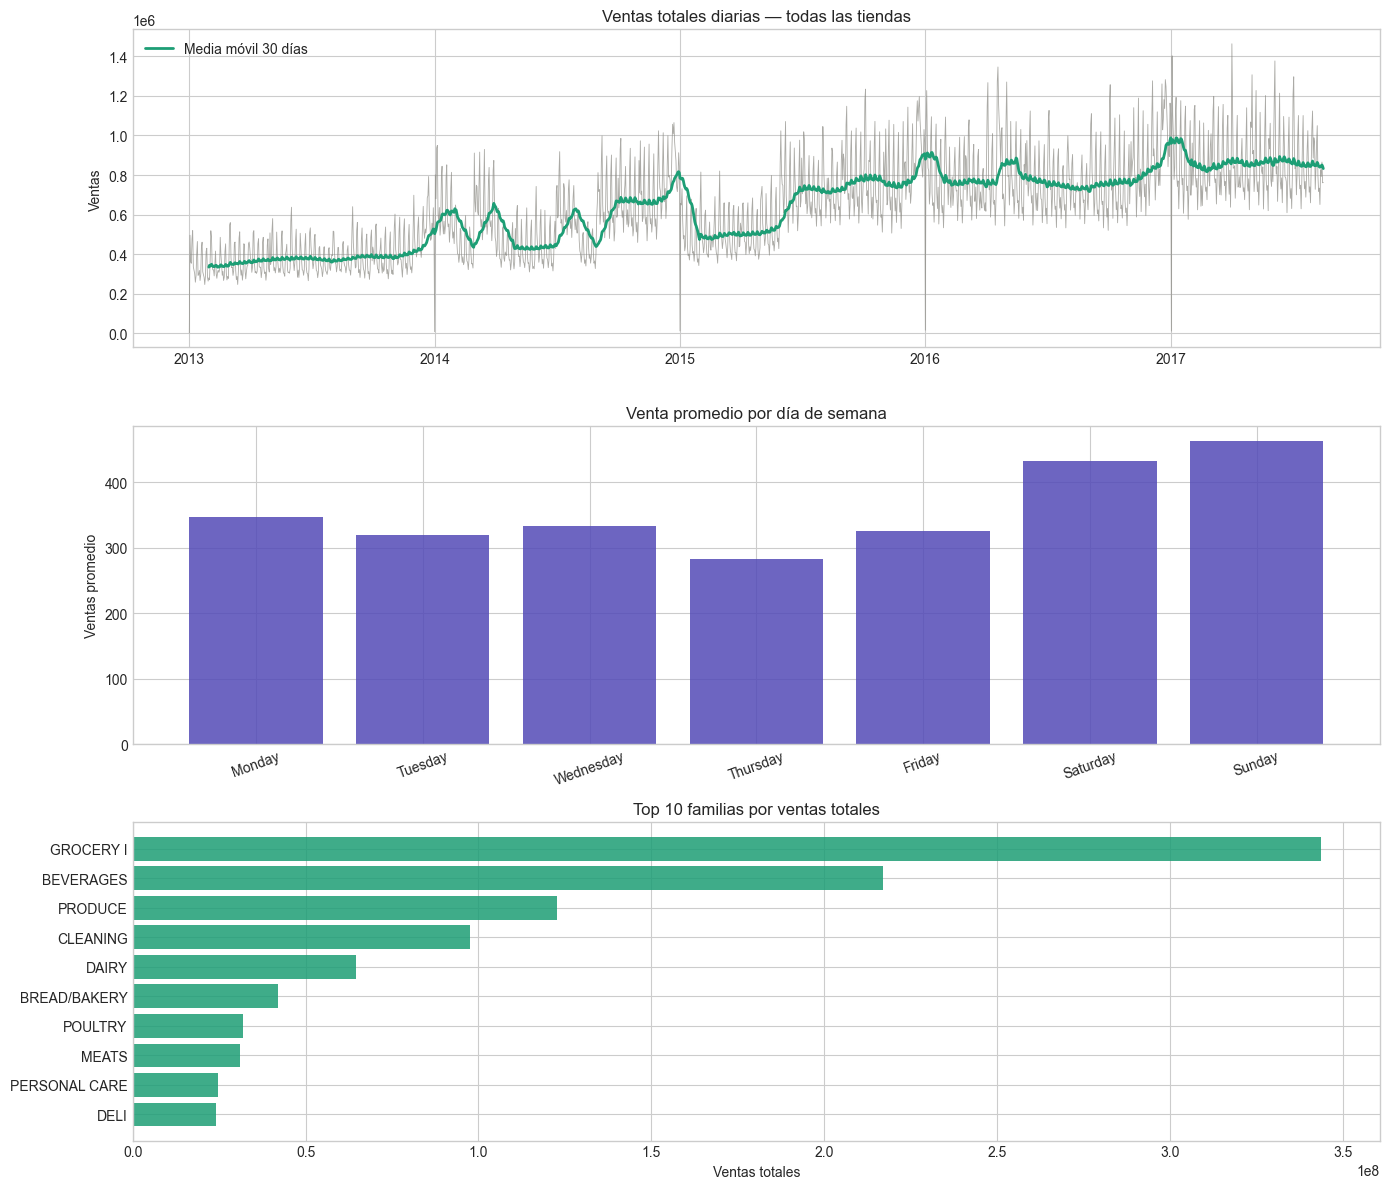


Top familia por volumen: GROCERY I


In [4]:
# ── EDA Visual completo
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Tendencia general de ventas
daily = train.groupby('date')['sales'].sum().reset_index() # Ventas totales por día
axes[0].plot(daily['date'], daily['sales'], color='#888780', linewidth=0.6, alpha=0.7) # Ventas diarias para todas las tiendas
axes[0].plot(daily['date'], daily['sales'].rolling(30).mean(),  # Media móvil 30 días para suavizar la tendencia encontrar patrones a largo plazo
             color='#1D9E75', linewidth=2, label='Media móvil 30 días')
axes[0].set_title('Ventas totales diarias — todas las tiendas')
axes[0].set_ylabel('Ventas')
axes[0].legend()

# 2. Ventas promedio por día de semana
train['dow'] = train['date'].dt.day_name() # Extraemos el día de la semana para analizar patrones semanales
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = train.groupby('dow')['sales'].mean().reindex(order) # Calculamos la venta promedio por día de la semana y ordenamos los días correctamente
axes[1].bar(dow_avg.index, dow_avg.values, color='#534AB7', alpha=0.85)
axes[1].set_title('Venta promedio por día de semana')
axes[1].set_ylabel('Ventas promedio')
axes[1].tick_params(axis='x', rotation=20)

# 3. Top 10 familias por volumen total (excluyendo ceros)
family_vol = (train[train['sales'] > 0]
              .groupby('family')['sales']
              .sum()
              .sort_values(ascending=True)
              .tail(10))
axes[2].barh(family_vol.index, family_vol.values, color='#1D9E75', alpha=0.85)
axes[2].set_title('Top 10 familias por ventas totales')
axes[2].set_xlabel('Ventas totales')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop familia por volumen: {family_vol.index[-1]}")

In [5]:
# ── Filtrar GROCERY I y preparar para modelado
df_model = (train[train['family'] == 'GROCERY I']
            .groupby('date')
            .agg(sales=('sales', 'sum'), onpromotion=('onpromotion', 'sum'))
            .reset_index()
            .sort_values('date'))

# Merge con precio del petróleo (variable macroeconómica de Ecuador)
df_model = df_model.merge(oil.rename(columns={'dcoilwtico': 'oil_price'}), 
                          on='date', how='left')
df_model['oil_price'] = df_model['oil_price'].interpolate()  # Llenar fines de semana

def create_features(df):
    df = df.copy()
    # Calendario
    df['dayofweek']    = df['date'].dt.dayofweek
    df['month']        = df['date'].dt.month
    df['quarter']      = df['date'].dt.quarter
    df['year']         = df['date'].dt.year
    df['dayofyear']    = df['date'].dt.dayofyear
    df['is_weekend']   = (df['date'].dt.dayofweek >= 5).astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    
    # Lag features
    for lag in [1, 7, 14, 28]:
        df[f'lag_{lag}'] = df['sales'].shift(lag)
    
    # Rolling means
    for window in [7, 14, 30]:
        df[f'rolling_mean_{window}'] = df['sales'].shift(1).rolling(window).mean()
        df[f'rolling_std_{window}']  = df['sales'].shift(1).rolling(window).std()
    
    return df

df_model = create_features(df_model)
df_model = df_model.dropna()

print(f"Dataset listo: {df_model.shape}")
print(f"Features: {[c for c in df_model.columns if c not in ['date','sales']]}")

Dataset listo: (1654, 21)
Features: ['onpromotion', 'oil_price', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'is_weekend', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30']


In [6]:
df_model.head()

,date,sales,onpromotion,oil_price,dayofweek,month,quarter,year,dayofyear,is_weekend,...,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
30,2013-01-31,106030.0,0,97.650000,3,1,1,2013,31,0,...,109595.0,96882.0,103443.0,144878.0,123744.285714,29665.224948,127162.071429,28943.499957,130873.666667,40873.633724
31,2013-02-01,143725.0,0,97.460000,4,2,1,2013,32,0,...,106030.0,107648.0,106982.0,135754.0,125051.142857,28461.704748,127346.857143,28788.262191,134384.666667,33088.791065
32,2013-02-02,209880.0,0,97.043333,5,2,1,2013,33,1,...,143725.0,159843.0,165079.0,188356.0,130205.000000,28048.528417,129971.357143,28461.872841,132441.500000,30597.837055
33,2013-02-03,200916.0,0,96.626667,6,2,1,2013,34,1,...,209880.0,172363.0,180666.0,207297.0,137353.142857,40481.153300,133171.428571,34574.885160,134608.233333,33657.408925
34,2013-02-04,145431.0,0,96.210000,0,2,1,2013,35,0,...,200916.0,115001.0,122481.0,133189.0,141432.142857,45699.054802,134617.857143,37049.652084,136780.300000,35770.188427


Esto incorpora el precio del petróleo como variable externa, que es relevante porque Ecuador es una economía petrolera y afecta el consumo...orque la demanda tiene memoria. Si esta semana vendiste mucho, probablemente la semana que viene también. XGBoost aprende esos patrones automáticamente cuando le das los lags como features.En demand planning esto se traduce directamente: un coordinador revisa las ventas de la semana pasada y del mes pasado para proyectar el pedido de la siguiente semana. El modelo hace exactamente lo mismo, pero con matemáticas.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor

# ── Split temporal — NUNCA aleatorio en series de tiempo
FEATURE_COLS = [c for c in df_model.columns if c not in ['date', 'sales']]
X = df_model[FEATURE_COLS]
y = df_model['sales']
dates = df_model['date']

split_date = df_model['date'].max() - pd.Timedelta(days=90)
X_train = X[dates <= split_date]
X_test  = X[dates > split_date]
y_train = y[dates <= split_date]
y_test  = y[dates > split_date]

print(f"Entrenamiento: {X_train.shape[0]} días hasta {split_date.date()}")
print(f"Test:          {X_test.shape[0]} días (últimos 90 días)")

# ── Función de métricas
def evaluar(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real.values - y_pred) / (y_real.values + 1))) * 100
    print(f"{nombre:30s} → RMSE: {rmse:,.0f} | MAPE: {mape:.1f}%")
    return rmse, mape

# ── Baseline: media móvil 7 días
baseline_pred = df_model[dates > split_date]['rolling_mean_7'].values
rmse_base, mape_base = evaluar("Baseline (media móvil 7d)", y_test, baseline_pred)

# ── Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, 
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rmse_rf, mape_rf = evaluar("Random Forest", y_test, rf_pred)

# ── XGBoost con GridSearch
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(XGBRegressor(random_state=42, verbosity=0),
                    param_grid, cv=tscv,
                    scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

xgb_best = grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)
rmse_xgb, mape_xgb = evaluar("XGBoost (optimizado)", y_test, xgb_pred)

print(f"\nMejores hiperparámetros XGBoost: {grid.best_params_}")
print(f"\nMejora MAPE vs Baseline: {((mape_base - mape_xgb) / mape_base * 100):.1f}%")

Entrenamiento: 1564 días hasta 2017-05-17
Test:          90 días (últimos 90 días)
Baseline (media móvil 7d)      → RMSE: 51,084 | MAPE: 15.8%
Random Forest                  → RMSE: 22,830 | MAPE: 6.5%
XGBoost (optimizado)           → RMSE: 23,938 | MAPE: 6.2%

Mejores hiperparámetros XGBoost: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

Mejora MAPE vs Baseline: 60.6%


Calcula dos métricas por modelo. RMSE te dice el error en unidades absolutas de ventas. MAPE te dice el error en porcentaje
baseline...Antes de usar ML, siempre comparas contra algo simple. Aquí el baseline es la media de los últimos 7 días. Si tu modelo XGBoost no le gana a este promedio simple, el modelo no sirve. Es el piso mínimo que debes superar.
 XGBoost construye árboles de forma secuencial — cada árbol corrige los errores del anterior, por eso suele ganarle a Random Forest en tabular data. GridSearch prueba todas las combinaciones posibles de hiperparámetros (2×2×2×2 = 16 combinaciones) y elige la que da menor error. El TimeSeriesSplit dentro del GridSearch asegura que cada validación cruzada también respete el orden temporal.
 Entrena cada modelo con los datos históricos
Le pide que prediga los últimos 90 días
Compara esas predicciones contra las ventas reales que ya conocemos
Te da el MAPE de cada uno

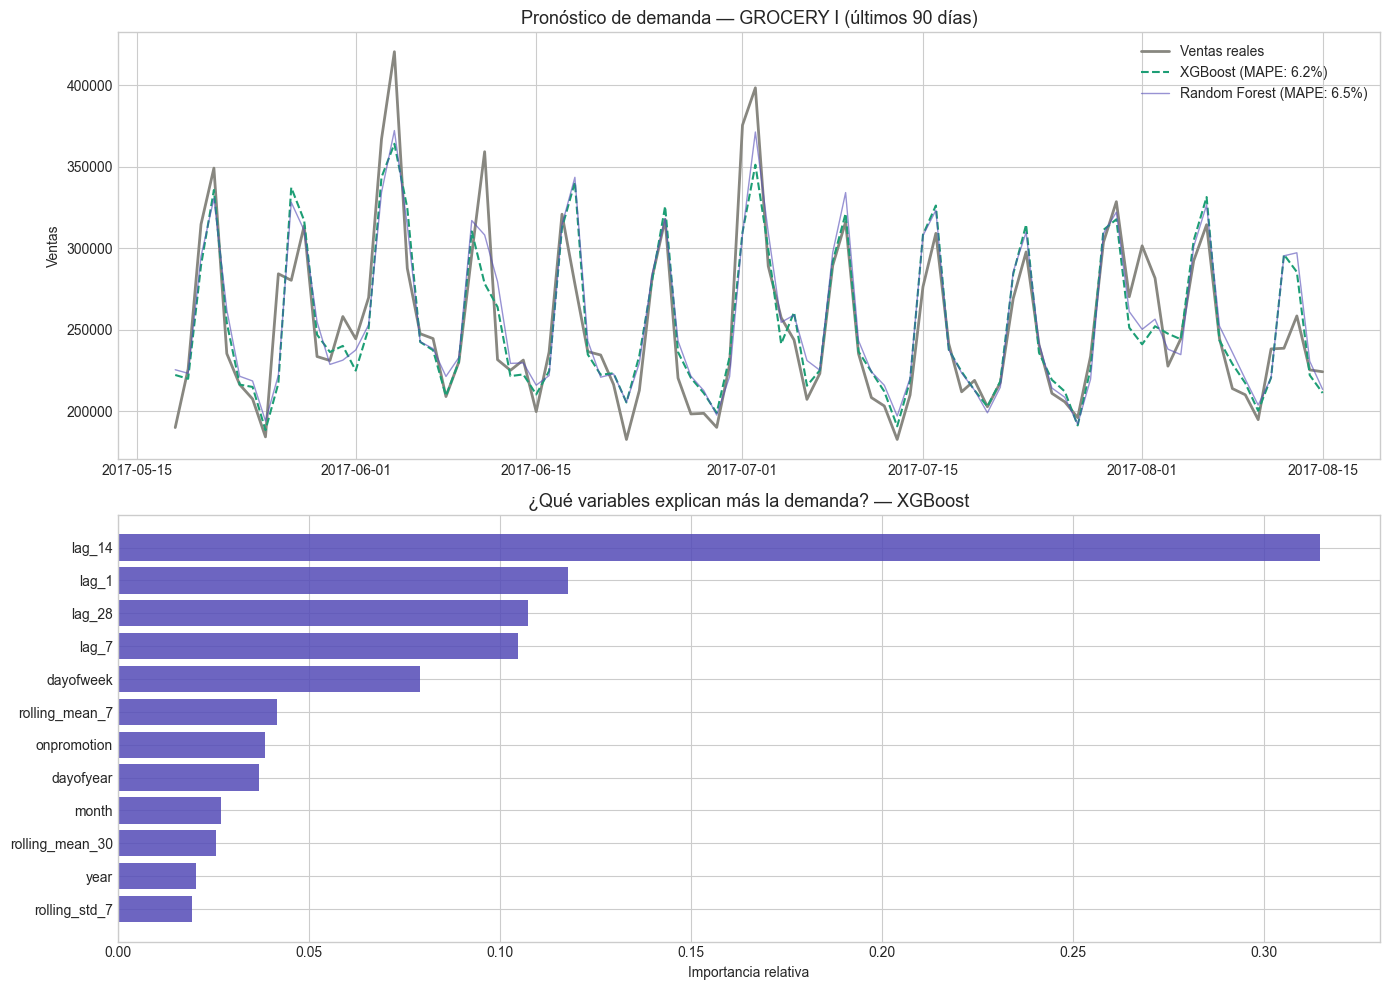

In [8]:
# ── Visualización: real vs predicho + importancia de variables
test_dates = df_model[dates > split_date]['date']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica 1 — Real vs Predicho
axes[0].plot(test_dates, y_test.values, 
             label='Ventas reales', color='#888780', linewidth=2)
axes[0].plot(test_dates, xgb_pred, 
             label=f'XGBoost (MAPE: 6.2%)', color='#1D9E75', 
             linewidth=1.5, linestyle='--')
axes[0].plot(test_dates, rf_pred, 
             label=f'Random Forest (MAPE: 6.5%)', color='#534AB7', 
             linewidth=1, alpha=0.6)
axes[0].set_title('Pronóstico de demanda — GROCERY I (últimos 90 días)', fontsize=13)
axes[0].set_ylabel('Ventas')
axes[0].legend()

# Gráfica 2 — Importancia de variables
feat_imp = (pd.Series(xgb_best.feature_importances_, index=FEATURE_COLS)
            .sort_values(ascending=True)
            .tail(12))
axes[1].barh(feat_imp.index, feat_imp.values, color='#534AB7', alpha=0.85)
axes[1].set_title('¿Qué variables explican más la demanda? — XGBoost', fontsize=13)
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

lag_14 es el driver más importante (0.32) — Las ventas de hace 14 días explican más la demanda actual que cualquier otra variable. En demand planning esto significa que el ciclo de reposición de esta categoría es quincenal. 

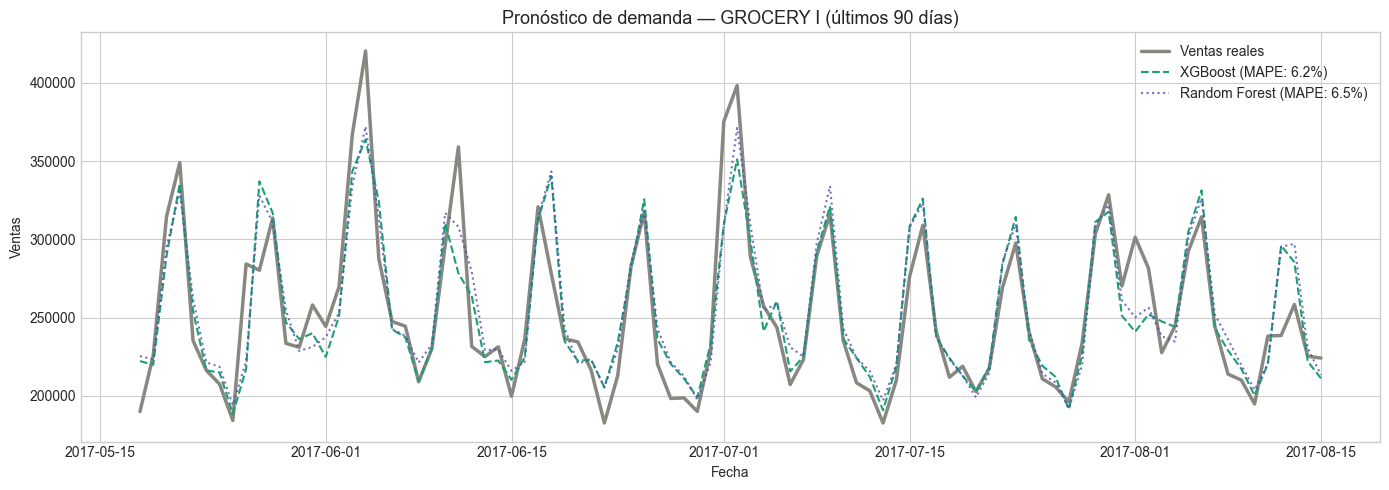

In [10]:
# ── Gráfica real vs predicho
test_dates = df_model[dates > split_date]['date']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_dates, y_test.values,
        label='Ventas reales', color='#888780', linewidth=2.5)
ax.plot(test_dates, xgb_pred,
        label='XGBoost (MAPE: 6.2%)', color='#1D9E75',
        linewidth=1.5, linestyle='--')
ax.plot(test_dates, rf_pred,
        label='Random Forest (MAPE: 6.5%)', color='#534AB7',
        linewidth=1.5, linestyle=':', alpha=0.8)

ax.set_title('Pronóstico de demanda — GROCERY I (últimos 90 días)', fontsize=13)
ax.set_ylabel('Ventas')
ax.set_xlabel('Fecha')
ax.legend()

plt.tight_layout()
plt.savefig('real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()